In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sys
import os

# Adicionando a pasta raiz ao path para conseguir importar a pasta mlp
sys.path.append(os.path.abspath('..'))

from mlp.network import MLP, LinearLayer
from mlp.activations import ReLU, Softmax
from mlp.optimizers import train, train_with_history

In [2]:
import os
import urllib.request
import numpy as np

# Define o caminho para salvar o arquivo de dados localmente
data_dir = '../data'
os.makedirs(data_dir, exist_ok=True)
data_path = os.path.join(data_dir, 'mnist.npz')

# Faz o download direto do arquivo bruto do MNIST se ele não existir localmente
if not os.path.exists(data_path):
    print("Baixando o dataset MNIST via URL direta...")
    url = "https://storage.googleapis.com/tensorflow/tf-keras-datasets/mnist.npz"
    urllib.request.urlretrieve(url, data_path)
    print("Download concluído com sucesso!")

# Carrega as matrizes nativamente usando apenas o NumPy
with np.load(data_path) as data:
    x_train = data['x_train']
    y_train = data['y_train']
    x_test = data['x_test']
    y_test = data['y_test']

# Pré-processamento manual idêntico ao original:
# 1. Flatten e Normalização (0 a 1)
x_train = x_train.reshape(x_train.shape[0], -1).astype('float32') / 255.0
x_test = x_test.reshape(x_test.shape[0], -1).astype('float32') / 255.0

# 2. One-hot encoding das labels
def to_one_hot(y, num_classes=10):
    return np.eye(num_classes)[y]

y_train_oh = to_one_hot(y_train)
y_test_oh = to_one_hot(y_test)

print(f"Dados carregados com sucesso utilizando 100% NumPy!")
print(f"Formato dos dados de Treino: {x_train.shape}, Teste: {x_test.shape}")

Baixando o dataset MNIST via URL direta...
Download concluído com sucesso!
Dados carregados com sucesso utilizando 100% NumPy!
Formato dos dados de Treino: (60000, 784), Teste: (10000, 784)


In [3]:
def evaluate(model, x, y):
    preds = np.argmax(model.forward(x), axis=1)
    return np.mean(preds == y)

final_model = MLP()
final_model.add_layer(LinearLayer(784, 128, 0.1), ReLU())
final_model.add_layer(LinearLayer(128, 64, 0.1), ReLU())
final_model.add_layer(LinearLayer(64, 10, 0.1), Softmax())

losses = train_with_history(final_model, x_train, y_train_oh)

print(f"\nTeste Acc: {evaluate(final_model, x_test, y_test)*100:.2f}%")

Epoch 1 Loss: 0.3451
Epoch 2 Loss: 0.1556
Epoch 3 Loss: 0.1111
Epoch 4 Loss: 0.0862
Epoch 5 Loss: 0.0694

Teste Acc: 97.50%


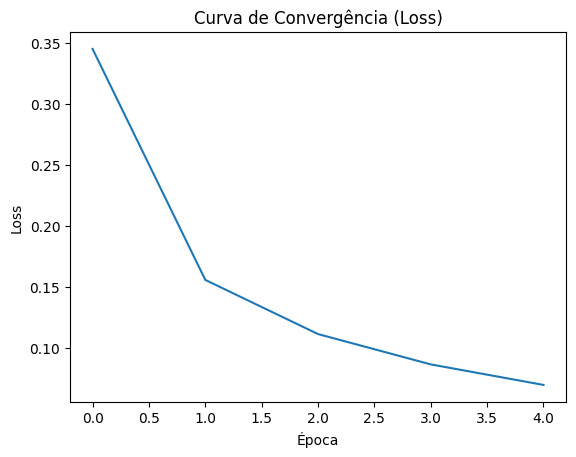

In [4]:
plt.plot(losses)
plt.title('Curva de Convergência (Loss)')
plt.xlabel('Época')
plt.ylabel('Loss')

# Salvando a figura na pasta de results como pedido
plt.savefig('../results/curva_de_loss.png')
plt.show()